In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [82]:
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Mall_Customers.csv"
df = pd.read_csv(url)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [83]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


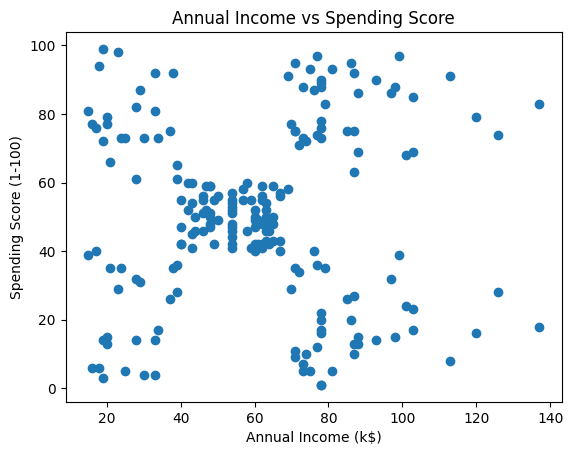

In [92]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.savefig("../static/Annual_IncomeXSpending_Score", dpi=150)
plt.show()

In [85]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X = X.values

print(X.shape)

(200, 2)


In [86]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

X_min = X.min(axis=0)
X_max = X.max(axis=0)

X_norm = (X - X_min) / (X_max - X_min)

df_norm = pd.DataFrame(
    X_norm,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

print(df_norm.head())

   Annual Income (k$)  Spending Score (1-100)
0            0.000000                0.387755
1            0.000000                0.816327
2            0.008197                0.051020
3            0.008197                0.775510
4            0.016393                0.397959


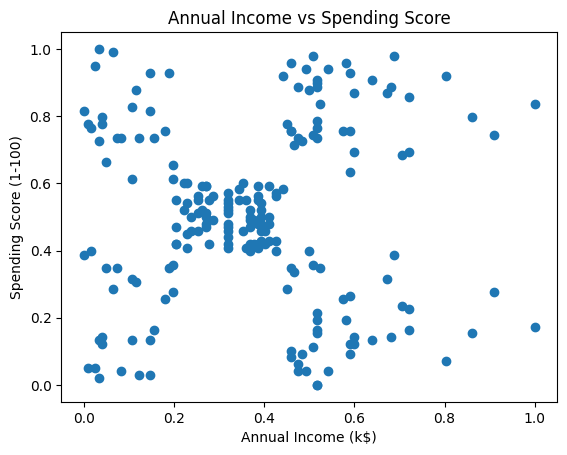

In [91]:
plt.scatter(df_norm["Annual Income (k$)"], df_norm["Spending Score (1-100)"])

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.savefig("../static/Annual_IncomeXSpending_Score Normalized", dpi=150)
plt.show()

In [88]:
import sys
sys.path.append('../src')
from kmeans import Kmeans

In [89]:
#np.random.seed(13)

model = model = Kmeans(k=5)

model.fit(X_norm)
print(model.clusters)

[4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4
 1 4 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 3 0 3 0 3 2 3 2 3 0 3 2 3 2 3 2 3 2 3 0 3 2 3 0 3
 2 3 2 3 2 3 2 3 2 3 2 3 0 3 2 3 2 3 2 3 2 0 2 3 2 3 2 3 2 3 2 3 2 3 2 3 0
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


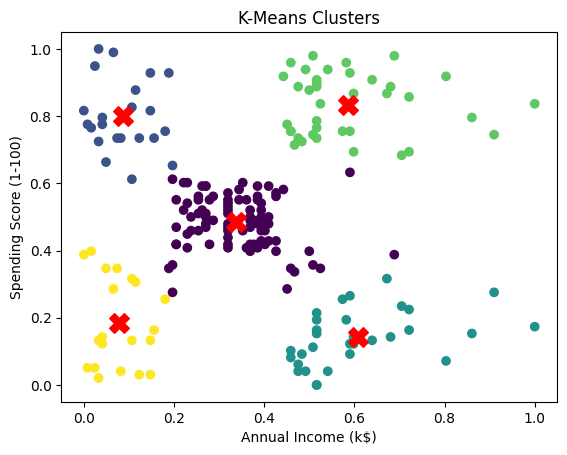

In [90]:
plt.scatter(X_norm[:, 0], X_norm[:, 1], c=model.clusters, cmap='viridis')
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], c='red', marker='X', s=200)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clusters")

plt.savefig("../static/K-means Clusters Normalized", dpi=150)
plt.show()